In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Create academic performance dataset with 1000 records
np.random.seed(42)
n = 1000

data = {
    'Student_ID': range(1, n+1),
    
    'Age': np.random.randint(18, 25, n).astype(float),
    
    'Math_Score': np.random.randint(40, 100, n).astype(float),
    
    'Science_Score': np.random.randint(40, 100, n).astype(float),
    
    'English_Score': np.random.randint(40, 100, n).astype(float),
    
    'Attendance': np.random.randint(50, 100, n).astype(float),
    
    'Study_Hours': np.random.randint(1, 10, n).astype(float),
    
    'Gender': np.random.choice(['Male', 'Female', 'M', 'F', 'male', 'female'], n),  # inconsistency
    
    'Grade': np.random.choice(['A', 'B', 'C', 'D', 'F', None, 'a', 'b'], n)         # inconsistency
}

df = pd.DataFrame(data)

# Inject missing values randomly
for col in ['Age', 'Math_Score', 'Science_Score', 'English_Score', 'Attendance', 'Study_Hours']:
    df.loc[np.random.choice(df.index, 40), col] = np.nan

# Inject outliers
df.loc[np.random.choice(df.index, 10), 'Math_Score']    = np.random.choice([150, 180, 200], 10)
df.loc[np.random.choice(df.index, 10), 'Science_Score'] = np.random.choice([160, 190, 210], 10)
df.loc[np.random.choice(df.index, 10), 'Attendance']    = np.random.choice([150, 170, 200], 10)
df.loc[np.random.choice(df.index, 10), 'Study_Hours']   = np.random.choice([50, 60, 80],   10)
df.loc[np.random.choice(df.index, 10), 'Age']           = np.random.choice([80, 90, 100],  10)

print("Dataset created successfully!")
print(f"Shape of dataset: {df.shape}")
print(df.head(10))

Dataset created successfully!
Shape of dataset: (1000, 9)
   Student_ID   Age  Math_Score  Science_Score  English_Score  Attendance  \
0           1  24.0        94.0           74.0           55.0        64.0   
1           2  90.0        81.0           59.0           51.0        76.0   
2           3  22.0        90.0           97.0           56.0        84.0   
3           4  24.0        56.0           88.0           55.0        82.0   
4           5  20.0        44.0           98.0           51.0        69.0   
5           6  22.0        68.0           81.0           47.0        65.0   
6           7  22.0        43.0           74.0           59.0        83.0   
7           8  24.0        49.0           89.0           42.0        51.0   
8           9  19.0        95.0          210.0           55.0        84.0   
9          10  20.0        56.0           56.0           69.0        89.0   

   Study_Hours  Gender Grade  
0          5.0    male     a  
1          2.0       M     C  
2

In [3]:
# Basic overview of dataset
print("=== Dataset Info ===")
print(df.info())

print("\n=== First 5 Rows ===")
print(df.head())

print("\n=== Basic Statistics ===")
print(df.describe())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Student_ID     1000 non-null   int64  
 1   Age            962 non-null    float64
 2   Math_Score     961 non-null    float64
 3   Science_Score  963 non-null    float64
 4   English_Score  961 non-null    float64
 5   Attendance     961 non-null    float64
 6   Study_Hours    960 non-null    float64
 7   Gender         1000 non-null   object 
 8   Grade          872 non-null    object 
dtypes: float64(6), int64(1), object(2)
memory usage: 70.4+ KB
None

=== First 5 Rows ===
   Student_ID   Age  Math_Score  Science_Score  English_Score  Attendance  \
0           1  24.0        94.0           74.0           55.0        64.0   
1           2  90.0        81.0           59.0           51.0        76.0   
2           3  22.0        90.0           97.0           56.0        

In [5]:
# Scan all variables for missing values
print("=== Missing Values Count ===")
print(df.isnull().sum())

print("\n=== Any Missing Values Present? ===")
print(df.isnull().values.any())

=== Missing Values Count ===
Student_ID         0
Age               38
Math_Score        39
Science_Score     37
English_Score     39
Attendance        39
Study_Hours       40
Gender             0
Grade            128
dtype: int64

=== Any Missing Values Present? ===
True


In [6]:
# Scan categorical variables for inconsistencies
print("=== Unique Values in Gender ===")
print(df['Gender'].unique())

print("\n=== Unique Values in Grade ===")
print(df['Grade'].unique())

print("\n=== Value Counts of Gender ===")
print(df['Gender'].value_counts())

print("\n=== Value Counts of Grade ===")
print(df['Grade'].value_counts())

=== Unique Values in Gender ===
['male' 'M' 'F' 'female' 'Female' 'Male']

=== Unique Values in Grade ===
['a' 'C' None 'D' 'F' 'b' 'B' 'A']

=== Value Counts of Gender ===
Gender
F         185
female    171
Female    170
M         167
male      164
Male      143
Name: count, dtype: int64

=== Value Counts of Grade ===
Grade
a    144
A    130
B    125
F    124
b    124
C    122
D    103
Name: count, dtype: int64


In [8]:
# Fix inconsistencies in categorical columns
df['Gender'] = df['Gender'].str.strip().str.capitalize()
df['Gender'] = df['Gender'].replace({'M': 'Male', 'F': 'Female'})

df['Grade'] = df['Grade'].str.strip().str.upper()

print("=== Gender after fixing ===")
print(df['Gender'].value_counts())

print("\n=== Grade after fixing ===")
print(df['Grade'].value_counts())

=== Gender after fixing ===
Gender
Female    526
Male      474
Name: count, dtype: int64

=== Grade after fixing ===
Grade
A    274
B    249
F    124
C    122
D    103
Name: count, dtype: int64


In [10]:
# Fill missing values in numeric columns with median
num_cols = ['Age', 'Math_Score', 'Science_Score', 'English_Score', 'Attendance', 'Study_Hours']

for col in num_cols:
    median_val = df[col].median()
    df[col]=df[col].fillna(median_val)
    print(f"{col} -> filled with median: {median_val}")

print("\n=== Missing Values After Filling ===")
print(df.isnull().sum())

Age -> filled with median: 21.0
Math_Score -> filled with median: 71.0
Science_Score -> filled with median: 70.0
English_Score -> filled with median: 69.0
Attendance -> filled with median: 75.0
Study_Hours -> filled with median: 5.0

=== Missing Values After Filling ===
Student_ID         0
Age                0
Math_Score         0
Science_Score      0
English_Score      0
Attendance         0
Study_Hours        0
Gender             0
Grade            128
dtype: int64


In [ ]:
# Fill missing values in categorical columns with mode
cat_cols = ['Gender', 'Grade']

for col in cat_cols:
    mode_val = df[col].mode()[0]
    df[col].fillna(mode_val, inplace=True)
    print(f"{col} -> filled with mode: {mode_val}")

print("\n=== Missing Values After Filling Categorical ===")
print(df.isnull().sum())

print("\nAll missing values handled successfully!")

In [12]:
# Fill missing values in categorical columns with mode
cat_cols = ['Gender', 'Grade']

for col in cat_cols:
    mode_val = df[col].mode()[0]
    df[col]=df[col].fillna(mode_val)
    print(f"{col} -> filled with mode: {mode_val}")

print("\n=== Missing Values After Filling Categorical ===")
print(df.isnull().sum())

print("\nAll missing values handled successfully!")

Gender -> filled with mode: Female
Grade -> filled with mode: A

=== Missing Values After Filling Categorical ===
Student_ID       0
Age              0
Math_Score       0
Science_Score    0
English_Score    0
Attendance       0
Study_Hours      0
Gender           0
Grade            0
dtype: int64

All missing values handled successfully!


In [13]:
# Fix None values using replace() then drop remaining NaN using dropna()
df['Gender'] = df['Gender'].replace({None: df['Gender'].mode()[0]})
df['Grade']  = df['Grade'].replace({None: df['Grade'].mode()[0]})

print("=== After replace() ===")
print(df.isnull().sum())

# Drop any remaining null rows if any
df.dropna(inplace=True)

print("\n=== After dropna() ===")
print(df.isnull().sum())
print(f"\nDataset shape after cleaning: {df.shape}")
print("All missing values handled successfully!")

=== After replace() ===
Student_ID       0
Age              0
Math_Score       0
Science_Score    0
English_Score    0
Attendance       0
Study_Hours      0
Gender           0
Grade            0
dtype: int64

=== After dropna() ===
Student_ID       0
Age              0
Math_Score       0
Science_Score    0
English_Score    0
Attendance       0
Study_Hours      0
Gender           0
Grade            0
dtype: int64

Dataset shape after cleaning: (1000, 9)
All missing values handled successfully!


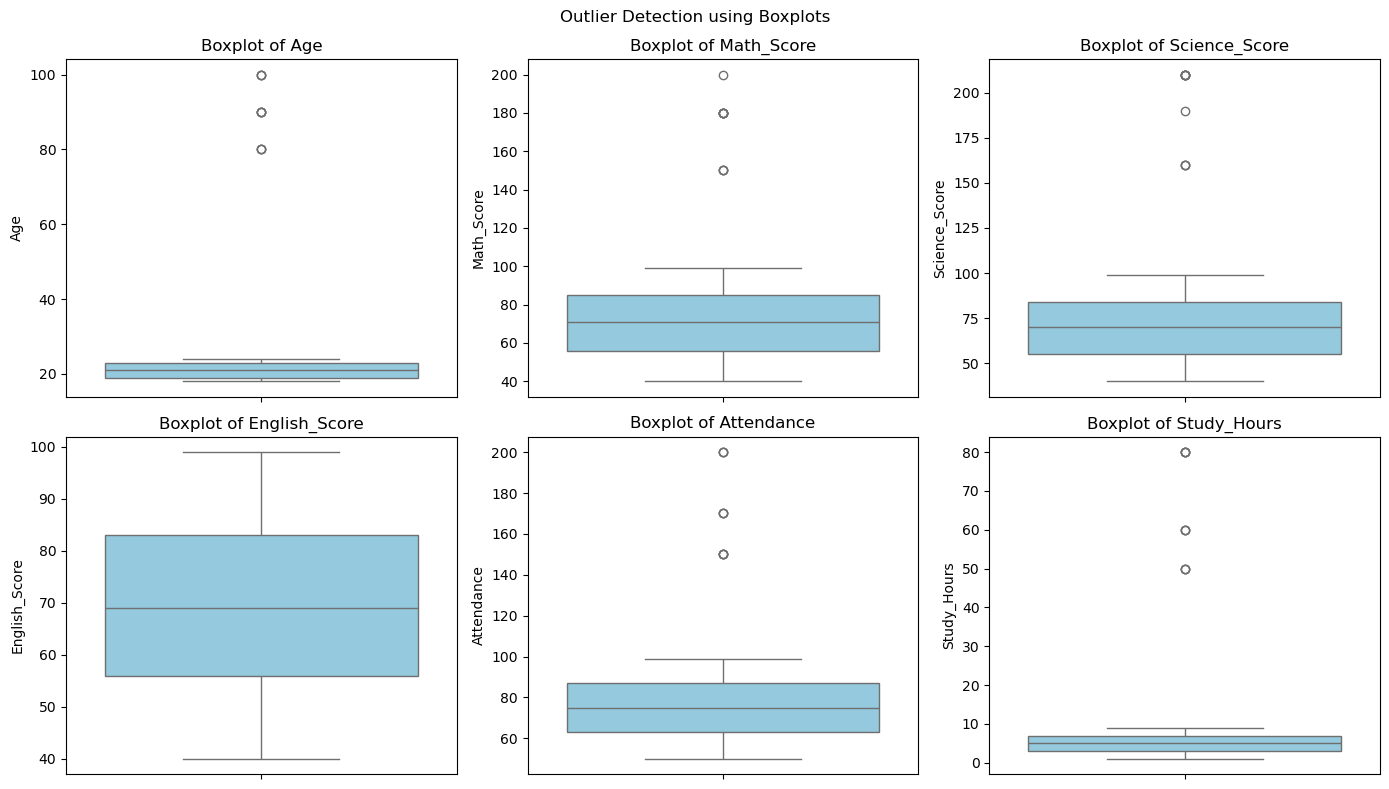

Boxplots plotted successfully!


In [14]:
# Visualize outliers using boxplot
num_cols = ['Age', 'Math_Score', 'Science_Score', 'English_Score', 'Attendance', 'Study_Hours']

plt.figure(figsize=(14, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')

plt.suptitle('Outlier Detection using Boxplots')
plt.tight_layout()
plt.show()

print("Boxplots plotted successfully!")

In [ ]:
# # Boxplot visually shows outliers as points beyond
# the whiskers so we can identify which columns have outliers.

In [15]:
# Detect and remove outliers using IQR method
num_cols = ['Age', 'Math_Score', 'Science_Score', 'English_Score', 'Attendance', 'Study_Hours']

print("=== Outliers Detected per Column ===")
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col} -> Outliers: {len(outliers)} | Lower: {lower:.2f} | Upper: {upper:.2f}")

# Remove outliers
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

print(f"\nDataset shape after removing outliers: {df.shape}")
print("Outliers removed successfully!")

=== Outliers Detected per Column ===
Age -> Outliers: 10 | Lower: 13.00 | Upper: 29.00
Math_Score -> Outliers: 10 | Lower: 12.50 | Upper: 128.50
Science_Score -> Outliers: 10 | Lower: 11.50 | Upper: 127.50
English_Score -> Outliers: 0 | Lower: 15.50 | Upper: 123.50
Attendance -> Outliers: 10 | Lower: 27.00 | Upper: 123.00
Study_Hours -> Outliers: 10 | Lower: -3.00 | Upper: 13.00

Dataset shape after removing outliers: (951, 9)
Outliers removed successfully!


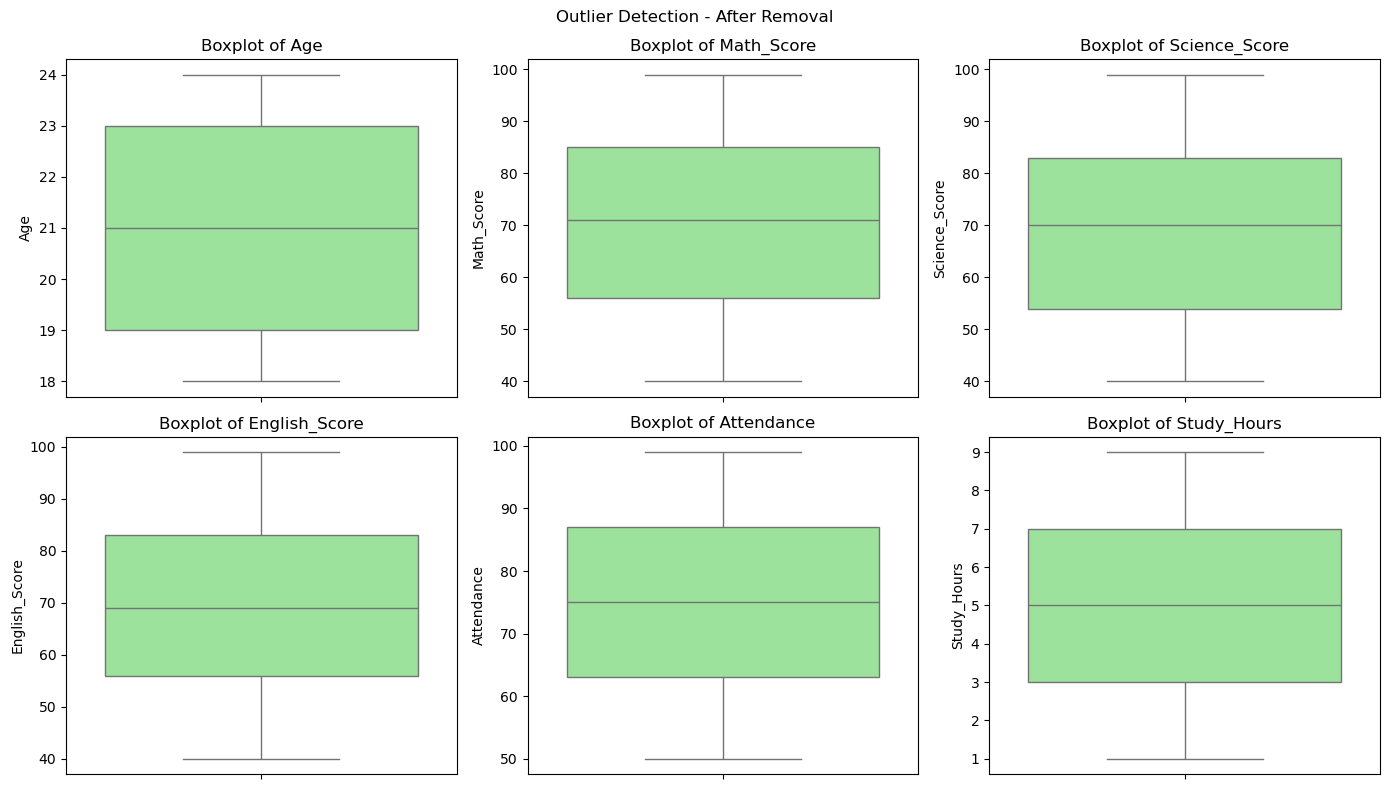

Boxplots after outlier removal plotted successfully!


In [16]:
# Visualize after outlier removal
plt.figure(figsize=(14, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'Boxplot of {col}')

plt.suptitle('Outlier Detection - After Removal')
plt.tight_layout()
plt.show()
print("Boxplots after outlier removal plotted successfully!")

In [19]:
# -first we check skewness to decide which transformation to apply.

In [ ]:
# 1. Symmetric      (Skewness =  0) → Balanced
# 2. Positively Skewed (Skewness > 0) → Right-tailed-Most data is on the left (low values)
# 3. Negatively Skewed (Skewness < 0) → Left-tailed-Most data is on the right (high values)

=== Skewness Before Transformation ===
Age              0.002439
Math_Score      -0.083852
Science_Score    0.024837
English_Score    0.047546
Attendance      -0.017358
Study_Hours     -0.040668
dtype: float64


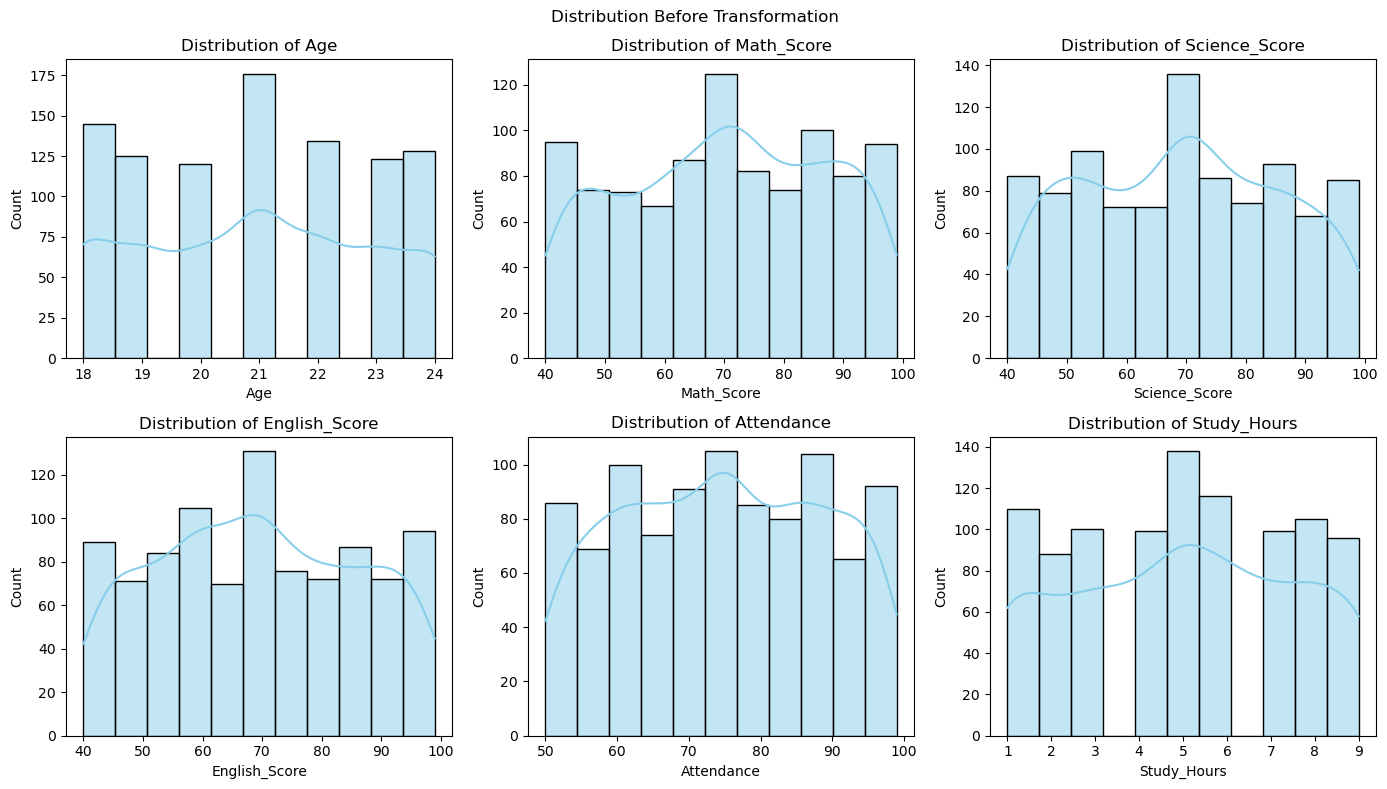

Skewness and distribution checked successfully!


In [25]:
# Check skewness of all numeric columns
print("=== Skewness Before Transformation ===")
print(df[num_cols].skew())

# Plot histogram to visualize distribution
plt.figure(figsize=(14, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')

plt.suptitle('Distribution Before Transformation')
plt.tight_layout()
plt.show()
print("Skewness and distribution checked successfully!")

Skewness of Study_Hours before transformation: -0.0407
Skewness of Study_Hours after log transformation: -0.6947


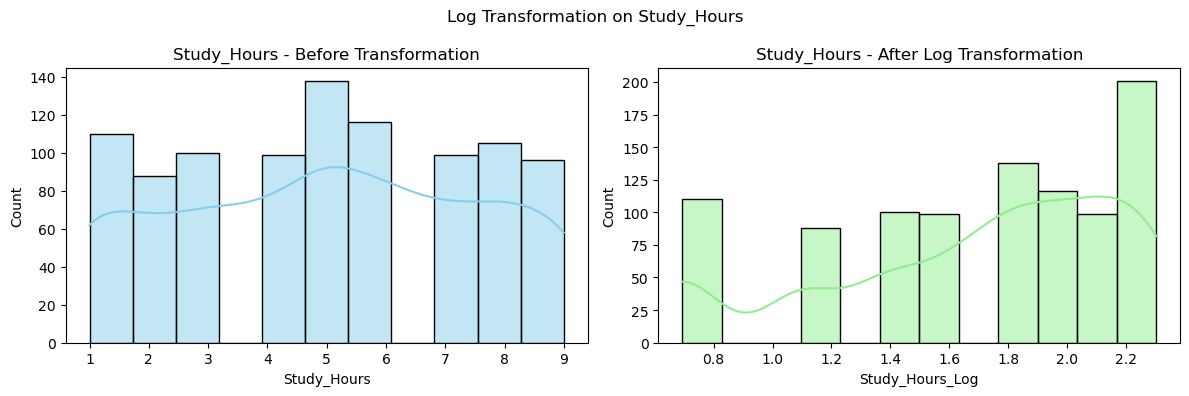

Log transformation applied successfully!


In [20]:
# Apply log transformation to reduce skewness in Study_Hours
print(f"Skewness of Study_Hours before transformation: {df['Study_Hours'].skew():.4f}")

# Apply log transformation
df['Study_Hours_Log'] = np.log1p(df['Study_Hours'])

print(f"Skewness of Study_Hours after log transformation: {df['Study_Hours_Log'].skew():.4f}")

# Plot before and after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['Study_Hours'], kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Study_Hours - Before Transformation')

sns.histplot(df['Study_Hours_Log'], kde=True, color='lightgreen', ax=axes[1])
axes[1].set_title('Study_Hours - After Log Transformation')

plt.suptitle('Log Transformation on Study_Hours')
plt.tight_layout()
plt.show()
print("Log transformation applied successfully!")

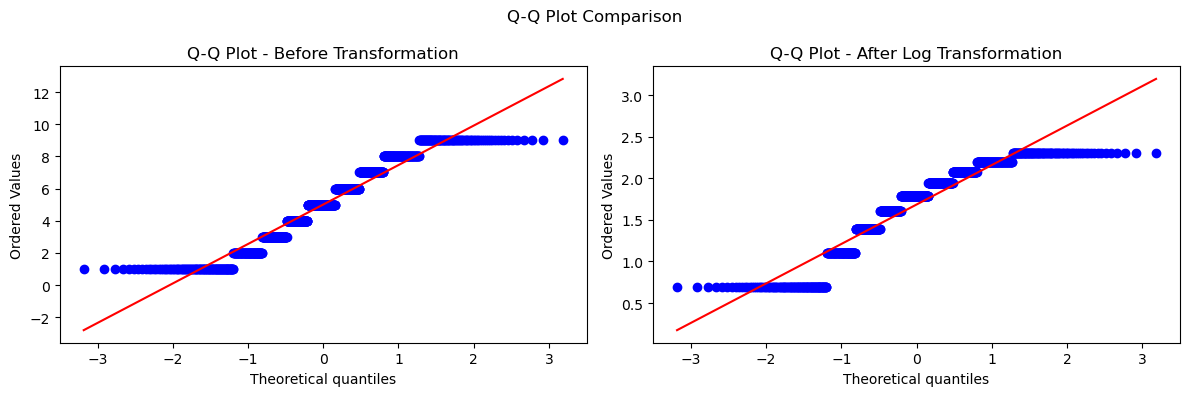

Q-Q plots plotted successfully!


In [21]:
# Q-Q plot to check if transformation resulted in normal distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

stats.probplot(df['Study_Hours'], dist="norm", plot=axes[0])
axes[0].set_title('Q-Q Plot - Before Transformation')

stats.probplot(df['Study_Hours_Log'], dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot - After Log Transformation')

plt.suptitle('Q-Q Plot Comparison')
plt.tight_layout()
plt.show()
print("Q-Q plots plotted successfully!")

In [ ]:
#Q-Q plot confirms if data follows normal distribution after transformation 
# points should fall on straight line.

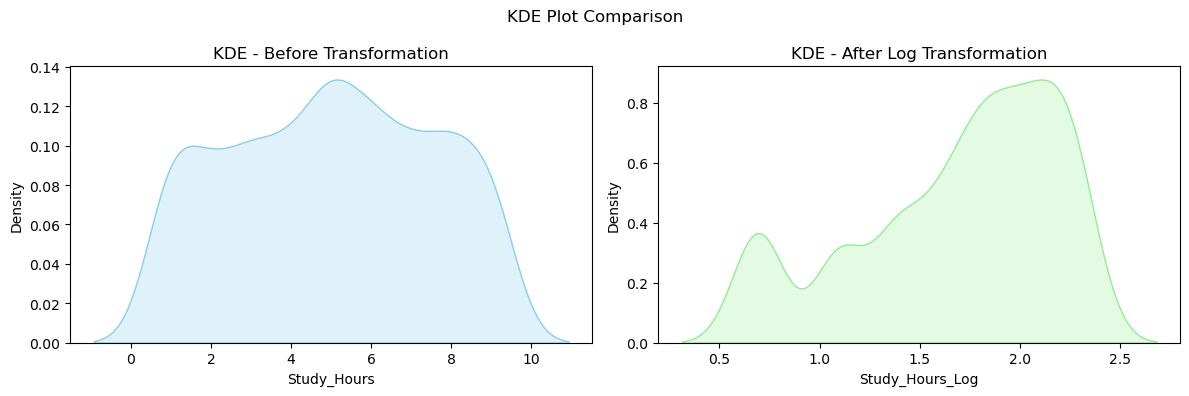

KDE plots plotted successfully!


In [22]:
# KDE plot before and after transformation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.kdeplot(df['Study_Hours'], color='skyblue', fill=True, ax=axes[0])
axes[0].set_title('KDE - Before Transformation')

sns.kdeplot(df['Study_Hours_Log'], color='lightgreen', fill=True, ax=axes[1])
axes[1].set_title('KDE - After Log Transformation')

plt.suptitle('KDE Plot Comparison')
plt.tight_layout()
plt.show()
print("KDE plots plotted successfully!")

In [23]:
# Final overview of cleaned dataset
print("=== Final Dataset Info ===")
print(df.info())

print("\n=== Final Missing Values Check ===")
print(df.isnull().sum())

print("\n=== Final Dataset Statistics ===")
print(df.describe())

print("\n=== Final Dataset Shape ===")
print(f"Total Records: {df.shape[0]} | Total Columns: {df.shape[1]}")
print("\nData Wrangling Completed Successfully!")

=== Final Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
Index: 951 entries, 0 to 998
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Student_ID       951 non-null    int64  
 1   Age              951 non-null    float64
 2   Math_Score       951 non-null    float64
 3   Science_Score    951 non-null    float64
 4   English_Score    951 non-null    float64
 5   Attendance       951 non-null    float64
 6   Study_Hours      951 non-null    float64
 7   Gender           951 non-null    object 
 8   Grade            951 non-null    object 
 9   Study_Hours_Log  951 non-null    float64
dtypes: float64(7), int64(1), object(2)
memory usage: 81.7+ KB
None

=== Final Missing Values Check ===
Student_ID         0
Age                0
Math_Score         0
Science_Score      0
English_Score      0
Attendance         0
Study_Hours        0
Gender             0
Grade              0
Study_Hours_Log    0
dtype: 